# Chapter 13 - Data preparation

*This notebook contains all the sample code in Chapter 13.*


## Outline

- [Scikit-learn transformer API](#sk_api)
- [Preprocessing](#Preprocessing)
    - [Data imputation and augmentation](#Data_imputation)
    - [Handling categorical data](#Categorical)
    - [Normalization and standardization](#Normalization)
- [Feature selection](#Feature_selection)
    - [Supervised approach](#Supervised_approach)
    - [Unsupervised approach](#Unsupervised_approach)
- [Feature extraction](#Feature_extraction)
    - [Principal Component Analysis (PCA)](#PCA)
    - [Linear Discriminant Analysis (LDA)](#LDA)
    - [High-dimensional data visualization](#manifold_learning)
- [Scikit-learn pipeline](#Pipeline)

## Scikit-learn transformer API <a id="sk_api"></a>

The typical workflow for data transformation is as follows:

1. **Model selection**: import the appropriate transformer class:

2. **Model initialization**: instantiate the model with the desired hyperparameters:

3. **Model fitting**: fit the model to the (training) data:

4. **Data transformation**:

Some transformers also provide the useful and convenience method `fit_transform()`, which **combine** steps 3 and 4.

## Preprocessing <a id="Preprocessing"></a>


### Data imputation and augmentation <a id="Data_imputation"></a>


Scikit-learn offers two functions for **data imputation**:

1. `SimpleImputer`, which **replaces** missing values using a statistic measure (e.g. mean, median, or most frequent);
	
2. `KNNImputer`, which **imputes** mising values using $K$ nearest neighbors found in the training set. 


For example:

In [1]:
import numpy as np
from sklearn.impute import SimpleImputer

X = [[1, 2, np.nan], [3, 4, 3], [np.nan, 6, 5], [8, 8, 7]]

imp_mean = SimpleImputer(strategy='mean')
X_impm = imp_mean.fit_transform(X)
print(X_impm)

[[1. 2. 5.]
 [3. 4. 3.]
 [4. 6. 5.]
 [8. 8. 7.]]


Or, for the `KNNImputer`:

In [2]:
from sklearn.impute import KNNImputer

X = [[1, 2, np.nan], [3, 4, 3], [np.nan, 6, 5], [8, 8, 7]]

imp_knn = KNNImputer(n_neighbors=2)
X_impk = imp_knn.fit_transform(X)
print(X_impk)

[[1.  2.  4. ]
 [3.  4.  3. ]
 [5.5 6.  5. ]
 [8.  8.  7. ]]


**Data augmentation** refers to the generation of additional training samples by applying *transformations* to existing data.


### Handling categorical data <a id="Categorical"></a>


#### Label encoding

For **encoding** class labels:

In [3]:
y = ['M', 'F', 'F', 'M', 'F', 'M', 'M']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(y_enc)

[1 0 0 1 0 1 1]


In [4]:
list(le.classes_)

['F', 'M']

In order to transform labels **back** to the original encoding, we can use:

In [5]:
list(le.inverse_transform([0, 0, 1, 0, 1]))

['F', 'F', 'M', 'F', 'M']

#### Handling ordinal feature

To encode an *ordinal* features:

In [6]:
X = [['M'], ['S'], ['XL'], ['L'], ['S'], ['S'], ['M'], ['L'], ['XL'], ['L']]

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
X_enc = oe.fit_transform(X)
print(X_enc)

[[1.]
 [2.]
 [3.]
 [0.]
 [2.]
 [2.]
 [1.]
 [0.]
 [3.]
 [0.]]


In [7]:
list(oe.categories_)

[array(['L', 'M', 'S', 'XL'], dtype=object)]

In [8]:
list(oe.inverse_transform([[2], [0], [1], [0], [3]]))

[array(['S'], dtype=object),
 array(['L'], dtype=object),
 array(['M'], dtype=object),
 array(['L'], dtype=object),
 array(['XL'], dtype=object)]

One limitation of the `OrdinalEncoder` class is that it **encodes** values in the sequence $0, 1, 2, ..., K-1$, if we have $K$ categories. If we need a different association, we have to manually **map** valued by using a dictionary.


The manual mapping is quite **simple** if data are in a Pandas DataFrame, as shown in the following example:

In [9]:
import pandas as pd

df = pd.DataFrame([['green', 'M', 10.1, 'class2'],
                   ['red', 'L', 13.5, 'class1'],
                   ['blue', 'XL', 15.3, 'class2'],
                   ['red', 'S', 8.4, 'class1']])
df.columns = ['color', 'size', 'price', 'classlabel']

size_mapping = {'XL': 4, 'L': 3, 'M': 2, 'S': 1}

df['size'] = df['size'].map(size_mapping)
df

,color,size,price,classlabel
0,green,2,10.1,class2
1,red,3,13.5,class1
2,blue,4,15.3,class2
3,red,1,8.4,class1


#### Handling nominal feature: one hot encoding

The **one hot encoding** can be implemented by using the `OneHotEncoder` class of Scikit-learn:

In [10]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
X_enc = ohe.fit_transform(X).toarray()
print(X_enc)

[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


As usual, the `inverse_transform()` method can retrieve the original values.


The **one hot encoding** can be also implemented directly in Pandas, by using the `get_dummies` method:

In [11]:
df = pd.get_dummies(df[['price', 'color', 'size']])
df

,price,size,color_blue,color_green,color_red
0,10.1,2,False,True,False
1,13.5,3,False,False,True
2,15.3,4,True,False,False
3,8.4,1,False,False,True


#### Binary encoding

The *binary* encoding can be performed by using the `LabelBinarizer` and the `MultiLabelBinarizer` classes of Scikit-learn:

In [12]:
from sklearn.preprocessing import LabelBinarizer

x = [1, 2, 6, 4, 2]
lb = LabelBinarizer()
y = lb.fit_transform(x)
print(y)

[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]


In [13]:
from sklearn.preprocessing import MultiLabelBinarizer

X = [[1, 2], [6, 1], [4, 2]]
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(X)
print(Y)

[[1 1 0 0]
 [1 0 0 1]
 [0 1 1 0]]


#### Binning

The `Binarizer` class **binarizes** data (set feature values to 0 or 1) according to a *threshold*:

In [14]:
from sklearn.preprocessing import Binarizer

x = np.array([1, 2, 6, 4, 2])
bi = Binarizer(threshold=3.0)
y  = bi.fit_transform(x.reshape(-1, 1))
print(y)

[[0]
 [0]
 [1]
 [1]
 [0]]


Similarly, the `KBinsDiscretizer` **bins** continuous data into intervals:

In [15]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
y  = kbd.fit_transform(x.reshape(-1, 1))
print(y)

[[0.]
 [0.]
 [2.]
 [1.]
 [0.]]


### Normalization and standardization <a id="Normalization"></a>

#### Normalization

Although the **normalization** can be simply implemented in Python:

In [16]:
ex = np.array([0, 1, 2, 3, 4, 5])
ex_norm = (ex - ex.min())/(ex.max() - ex.min())
print(ex_norm)

[0.  0.2 0.4 0.6 0.8 1. ]


this can be implemented in Scikit-learn as:

In [17]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(ex[:,np.newaxis])
ex_norm = mms.transform(ex[:,np.newaxis])
print(ex_norm)

[[0. ]
 [0.2]
 [0.4]
 [0.6]
 [0.8]
 [1. ]]


We can also use **directly** the `fit_transform()` method:

In [18]:
mms = MinMaxScaler()
ex_norm = mms.fit_transform(ex[:,np.newaxis])
print(ex_norm)

[[0. ]
 [0.2]
 [0.4]
 [0.6]
 [0.8]
 [1. ]]


If we need an interval different from $[0, \, 1]$, we can use:

In **machine learning** applications, this procedure is implemented as:

In [19]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X = wine.data
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm  = mms.transform(X_test)

#### Standardization

The **standardization** can be directly implemented in Scikit-learn:

In [20]:
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std  = stdsc.transform(X_test)

#### Outliers reduction

Common approaches for detecting **outliers** include:
* values beyond three standard deviations from the mean;
* values beyond three scaled median absolute deviations (MAD);
* values outside 1.5 times the interquartile range (IQR).


The `RobustScaler` is designed to reduce the influence of outliers by using median and quantile-based scaling:

In [21]:
from sklearn.preprocessing import RobustScaler

rsc = RobustScaler()
X_train_norm = rsc.fit_transform(X_train)
X_test_norm  = rsc.transform(X_test)

If we need to change the quantile range:


In [22]:
rsc = RobustScaler(quantile_range=(10.0, 90.0))

Finally, **noise reduction** aims to remove unwanted variations in the data, often caused by measurement errors or sensor noise. This is typically achieved through filtering or smoothing techniques.


## Feature selection <a id="Feature_selection"></a>


### Supervised approach <a id="Supervised_approach"></a>


#### L1 regularization

Many models in Scikit-learn supports $L1$ regularization:

For the LogistRegression class, the $L1$ regularization is not compatible with the default solver. Hence we set it to liblinear:

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear')
model.fit(X_train_std, y_train)

y_model = model.predict(X_test_std)
acc = accuracy_score(y_test, y_model)
print("Test accuracy: {}% ".format(round(100*acc, 2)))

Test accuracy: 98.31% 


In [24]:
print(model.coef_[0,:])  # only for first class

[0.31385607 0.         0.         0.         0.         0.
 0.6881096  0.         0.         0.         0.         0.
 1.21211128]


Only **three** features are different from zero (1st, 7th, and 13th) for the first class, corresponding to: alcohol, flavanoids, and proline.


#### Sequential Feature Selection

The Sequential Feature Selector performs greedy feature selection by either **adding** (*forward selection*) or **removing** (*backward selection*) features:

In [25]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn, n_features_to_select=3, direction='backward')
sfs.fit(X_train_std, y_train)

X_train_select = sfs.transform(X_train_std)
X_test_select  = sfs.transform(X_test_std)

knn.fit(X_train_select, y_train)

# Print selected features
print(sfs.get_feature_names_out(wine.feature_names))

['alcohol' 'proanthocyanins' 'hue']


The **three** selected features were: alcohol, ash, and flavanoids.


#### Feature importance

Some estimators have a `feature_importances_` attribute that measures how a feature is **important** for the final decision. For exampe, using the **RandomForests**:

In [26]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train_std, y_train)

importance = clf.feature_importances_
print(importance)

[0.10752772 0.01830922 0.01728618 0.0360682  0.01472401 0.05316408
 0.14639659 0.01674263 0.03717633 0.18349481 0.07091337 0.11630213
 0.18189473]


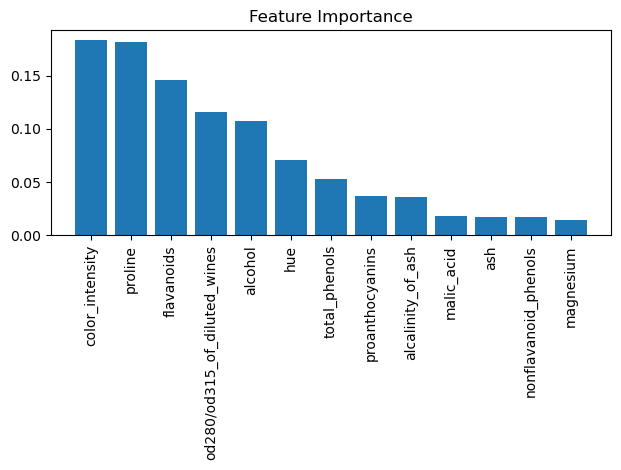

In [27]:
import matplotlib.pyplot as plt

indices = np.argsort(importance)[::-1]
feat_labels = wine.feature_names
feat_labels = [feat_labels[i] for i in indices]

plt.figure()
plt.bar(range(X_train.shape[1]), importance[indices], align='center')
plt.title('Feature Importance')
plt.xticks(range(X_train.shape[1]), feat_labels, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()

#### SelectFromModel

To **automate** feature selection based on importance, the `SelectFromModel` class can be used:

In [28]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(clf, threshold=0.1, prefit=True)
X_select = sfm.transform(X_train_std)
print('Number of selected features:', X_select.shape[1])

Number of selected features: 5


#### Recursive feature elimination

Recursive Feature Elimination (**RFE**) selects features by iteratively removing the least important one:

In [29]:
from sklearn.feature_selection import RFE

selector = RFE(clf, n_features_to_select=5)
selector = selector.fit(X_train, y_train)

# Select only the selected features
X_train_select = selector.transform(X_train_std)
X_test_select  = selector.transform(X_test_std)

# Print selected features
print(selector.get_feature_names_out(wine.feature_names))

['alcohol' 'flavanoids' 'color_intensity' 'od280/od315_of_diluted_wines'
 'proline']


#### Recursive feature elimination with cross-validation

An extension of this method is **RFECV**, which incorporates *cross-validation* to automatically determine the optimal number of features:

In [30]:
from sklearn.feature_selection import RFECV

selector = RFECV(clf, min_features_to_select=3, cv=5)
selector = selector.fit(X_train, y_train)

# Select only the selected features
X_train_select = selector.transform(X_train_std)
X_test_select  = selector.transform(X_test_std)

# Print selected features
print(selector.get_feature_names_out(wine.feature_names))

['alcohol' 'total_phenols' 'flavanoids' 'color_intensity' 'hue'
 'od280/od315_of_diluted_wines' 'proline']


#### Univariate feature selection

Univariate feature selection evaluates each feature individually using statistical tests. The `SelectKBest` selects the top $K$ features according to a specified scoring function:	

Available scoring functions include:
* **Classification**:
    1. `f_classif` (default): ANOVA F-value between label/feature;
    2. `chi2`: Chi-squared\ test (for non-negative features);
    3. `mutual_info_classif`: mutual information.
* **Regression**:
    1. `f_regression`: F-value between label/feature;
    2. `r_regression`: Pearson correlation coefficient;
    3. `mutual_info_regression`: mutual information.


For example:

In [31]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=5)
X_select = selector.fit_transform(X_train, y_train)
print(X_select.shape[1])

5


### Unsupervised approach <a id="Unsupervised_approach"></a>


#### Removing low-variance features

The `VarianceThreshold` class can be used as:

In [32]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1.0)
selector = selector.fit(X_train)

# Select only the selected features
X_train_select = selector.transform(X_train)
X_test_select  = selector.transform(X_test)

# Print selected features
print(selector.get_feature_names_out(wine.feature_names))

['malic_acid' 'alcalinity_of_ash' 'magnesium' 'color_intensity' 'proline']


Obviously, the features **must not** be *standardized*. Otherwise, all features have **unit** variance.


## Feature extraction <a id="Feature_extraction"></a>


### Principal Component Analysis (PCA) <a id="PCA"></a>


The *Principal Component Analysis* (**PCA**) aims to find an optimal linear transformation $\mathbf{y} = \mathbf{Wx}$, determining the **maximal variance** directions, as shown in the following figure.

In Scikit-learn, PCA can be implemented using the `PCA` class. The main parameter is `n_components`, which specifies the number of components to retain. If $0 < \texttt{n\_components} < 1$, it represents the fraction of total variance to preserve:

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
# pca = PCA(n_components=0.9)  # Keep 90% of variance
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)

print("Number of selected components:", pca.n_components_)
print("Percentage of variance explained:", sum(pca.explained_variance_ratio_))

clf = LogisticRegression()
clf.fit(X_train_pca, y_train)

acc = accuracy_score(y_test, y_model)
print("Test accuracy: {}%".format(round(100*acc,2)))

Number of selected components: 2
Percentage of variance explained: 0.562427969855845
Test accuracy: 98.31%


#### Kernel PCA

**Kernel PCA** is a nonlinear version of **PCA**.


**Kernel PCA** is available in Scikit-learn via the `KernelPCA`. We provide a first example on the *moon* dataset:

In [34]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.0, random_state=42)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)    # Evaluating PCA

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X)  # Evaluating KPCA


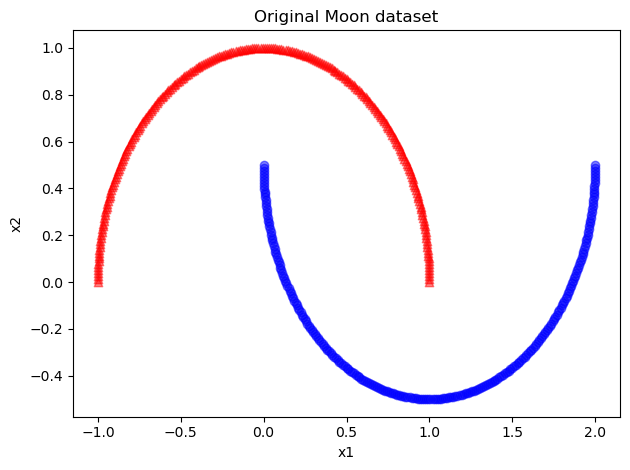

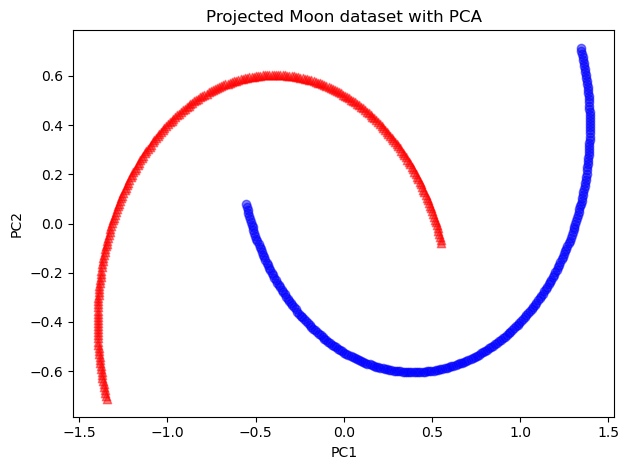

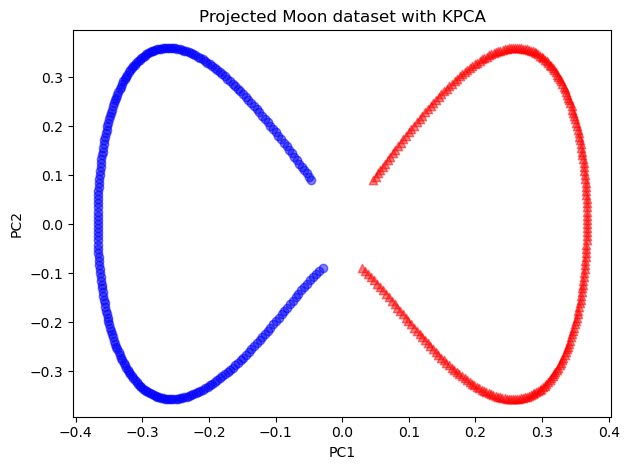

In [35]:
# Plotting the original dataset
plt.figure()
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='^', alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', alpha=0.5)
plt.title('Original Moon dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()


# Plotting the projected dataset with PCA
plt.figure()
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
            color='red', marker='^', alpha=0.5)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
            color='blue', marker='o', alpha=0.5)
plt.title('Projected Moon dataset with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()


# Plotting the projected dataset with KPCA
plt.figure()
plt.scatter(X_kpca[y == 0, 0], X_kpca[y == 0, 1],
            color='red', marker='^', alpha=0.5)
plt.scatter(X_kpca[y == 1, 0], X_kpca[y == 1, 1],
            color='blue', marker='o', alpha=0.5)
plt.title('Projected Moon dataset with KPCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

We provide a second example on the *circles* dataset:

In [36]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)    # Evaluating PCA

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_kpca = kpca.fit_transform(X)  # Evaluating KPCA


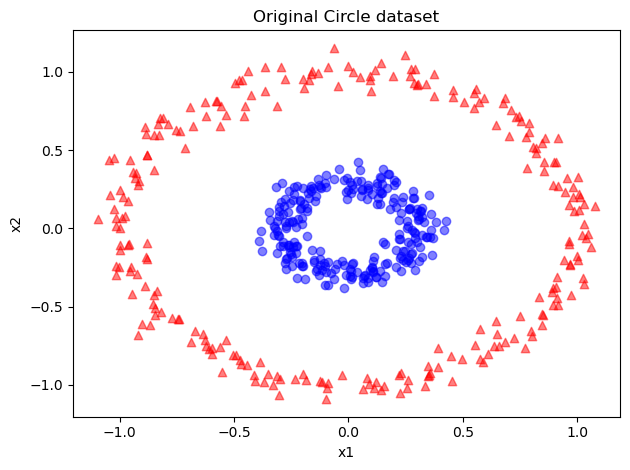

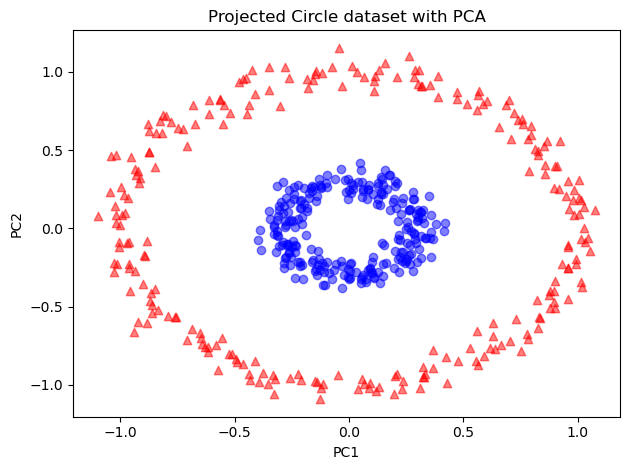

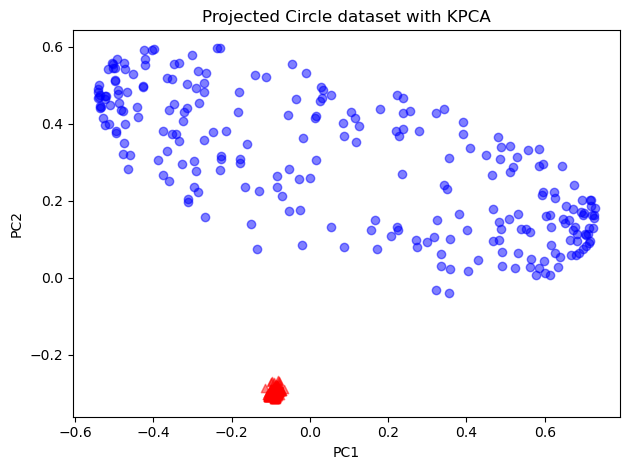

In [37]:
# Plotting the original dataset
plt.figure()
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='^', alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', alpha=0.5)
plt.title('Original Circle dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()


# Plotting the projected dataset with PCA
plt.figure()
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
            color='red', marker='^', alpha=0.5)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
            color='blue', marker='o', alpha=0.5)
plt.title('Projected Circle dataset with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()


# Plotting the projected dataset with KPCA
plt.figure()
plt.scatter(X_kpca[y == 0, 0], X_kpca[y == 0, 1],
            color='red', marker='^', alpha=0.5)
plt.scatter(X_kpca[y == 1, 0], X_kpca[y == 1, 1],
            color='blue', marker='o', alpha=0.5)
plt.title('Projected Circle dataset with KPCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

### Linear Discriminant Analysis (LDA) <a id="LDA"></a>

*Linear Discriminant Analysis* (**LDA**) is a supervised dimensionality reduction technique that seeks directions maximizing class separability.


In Scikit-learn, **LDA** is implemented as:

In [38]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda  = lda.transform(X_test_std)
print("Explained variance ratio:", sum(lda.explained_variance_ratio_))
		
clf = LogisticRegression()
clf.fit(X_train_lda, y_train)

acc = accuracy_score(y_test, y_model)
print("Test accuracy: {}%".format(round(100*acc,2)))

Explained variance ratio: 1.0
Test accuracy: 98.31%


### High-dimensional data visualization <a id="manifold_learning"></a>


There are many other approaches to nonlinear dimensionality reduction, generally known in literature as **Manifold Learning**. This kind of algorithms are based on the idea that the dimensionality of many datasets is only artificially high.

There are **several** methods of manifold learning:

* **Multidimensional scaling** (**MDS**): it seeks a low-dimensional representation of the data in which the distances respect well the distances in the original high-dimensional space. MDS is generally used for analyzing similarity or dissimilarity in data. 
	
* **Isomap**: it can be viewed as an extension of MDS or KPCA, which seeks a lower-dimensional embedding that maintains geodesic distances between all points. 
	
* **Locally linear embedding** (**LLE**): it seeks a lower-dimensional projection of the data which **preserves** distances within local neighborhoods. It can be thought of as a series of local PCA that are globally compared to find the best nonlinear embedding.
	
* **Spectral Embedding**: it is an approach to calculating a nonlinear embedding by using a spectral decomposition of the graph **Laplacian**.

* **t-SNE**: it converts affinities of data points to probabilities. The affinities in the original space are represented by Gaussian joint probabilities and the affinities in the embedded space are represented by Student's t-distributions.


All these approaches are implemented in Scikit-learn, with a **similar** syntax. A common parameter is the number of component (`n_components`), which represents the dimension of the **embedded** space. By default, it is set to **2**, in order to make a plot of the embedding.


C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\miche\anaconda3\envs\mtf\Lib\subprocess.py", line 1538, in _execute_chi

Dimension of input space: 64
Dimension of embedded space: 2


Text(0, 0.5, 'c2')

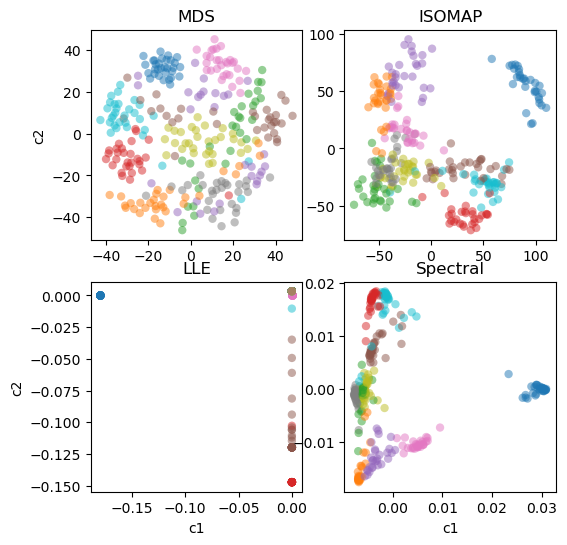

In [39]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import MDS
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import SpectralEmbedding

# Loading the dataset (from sklearn)
digits = datasets.load_digits()
X = digits.data
y = digits.target


# Performing the MDS embeddings
mds = MDS(n_components=2, normalized_stress='auto')
X_mds = mds.fit_transform(X[:300])

# Performing the ISOMAP embeddings
isomap = Isomap(n_components=2, n_neighbors=15)
X_isomap = isomap.fit_transform(X[:300])

# Performing the Locally linear embedding (LLE) embeddings
lle = LocallyLinearEmbedding(n_components=2)
X_lle = lle.fit_transform(X[:300])

# Performing the Spectral Embedding (SE) embeddings
se = SpectralEmbedding(n_components=2)
X_se = se.fit_transform(X[:300])

print("Dimension of input space:", X.shape[1])
print("Dimension of embedded space:", X_mds.shape[1])


# Plot all embeddings
fig, ax = plt.subplots(2, 2, figsize=(6 ,6))
ax[0, 0].set_title("MDS")
ax[0, 0].scatter(X_mds[:, 0], X_mds[:, 1], c=y[:300], 
            edgecolor='none', alpha=0.5, cmap='tab10')
ax[0, 1].set_title ("ISOMAP")
ax[0, 1].scatter(X_isomap[:, 0], X_isomap[:, 1], c=y[:300], 
            edgecolor='none', alpha=0.5, cmap='tab10')
ax[1, 0]. set_title ("LLE")
ax[1, 0].scatter(X_lle[:, 0], X_lle[:, 1], c=y[:300], 
            edgecolor='none', alpha=0.5, cmap='tab10')
ax[1, 1]. set_title ("Spectral")
ax[1, 1].scatter(X_se[:, 0], X_se[:, 1], c=y[:300], 
            edgecolor='none', alpha=0.5, cmap='tab10')

ax[1, 1]. set_xlabel ("c1")
ax[1, 0]. set_xlabel ("c1")
ax[0, 0]. set_ylabel ("c2")
ax[1, 0]. set_ylabel ("c2")

As an example, **t-SNE** can be used to visualize high-dimensional data such as *handwritten digits* (originally lying in a 64-dimensional space):

Dimension of input space: 64
Dimension of embedded space: 2


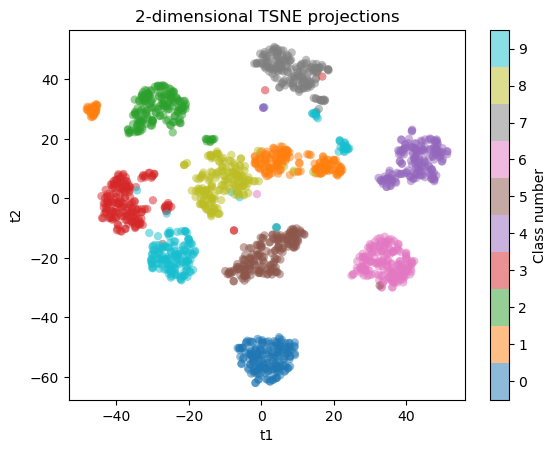

In [40]:
from sklearn.manifold import TSNE

# Loading the dataset (from sklearn)
digits = datasets.load_digits()
X = digits.data
y = digits.target

tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(X)

print("Dimension of input space:", X.shape[1])
print("Dimension of embedded space:", X_embedded.shape[1])

# Visualizing the embedded space
plt.figure()
sc = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, 
            edgecolor='none', alpha=0.5, cmap='tab10')
plt.xlabel('t1')
plt.ylabel('t2')
plt.title('2-dimensional TSNE projections')
cb = plt.colorbar(sc, label='Class number', ticks=range(10))
# cb.set_ticklabels(np.arange(1,11))
plt.clim(-0.5, 9.5)

The previous code snippet shows that the t-SNE approach has effectively **reduced** the $8 \times 8 = 64$ dimensions of the input space (the image pixels) to only 2 dimensions. 

## Scikit-learn pipeline <a id="Pipeline"></a>

Data often require one or more preprocessing transformations before a classification or regression algorithm can be applied. For example, numerical features may need to be standardized before training a logistic regression model. In addition, a dimensionality-reduction technique such as principal component analysis (PCA) may be used when the original feature space is high-dimensional or contains strongly correlated variables.

Instead of applying each transformer and estimator separately, Scikit-learn allows them to be combined into a single object using the `Pipeline` class. A pipeline chains a sequence of preprocessing operations with a final estimator and offers several advantages:
- the entire sequence can be trained by calling `fit` only once, and predictions can subsequently be obtained by calling `predict`;
- the hyperparameters of all the steps can be optimized jointly, for example through grid search;
- during cross-validation, each transformer is fitted only on the training portion of the current fold and then applied to the validation portion, thereby reducing the risk of *data leakage*;
- the same preprocessing operations are applied consistently to both the training and test data.

> All intermediate steps of a pipeline must implement both the `fit` and `transform` methods. Therefore, they must be transformers. The final step only needs to implement `fit` and may be, for example, a classifier, a regressor, or another transformer.

A Scikit-learn pipeline can be constructed in two main ways.

1. Using the `Pipeline` class with a list of `(name, estimator)` pairs:

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as STD

estimators = [('std', STD()), ('reduce_dim', PCA()), ('clf', SVC())]
pipe = Pipeline(estimators)

2. Using the `make\_pipeline` function, which automatically assigns a name to each step:

In [42]:
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(STD(), PCA(), SVC())

In both cases, the pipeline can be trained and used for prediction as follows:

In [43]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

When `fit` is called, the pipeline sequentially fits each intermediate transformer and uses it to transform the data. The transformed data are then passed to the next step, and the final estimator is fitted on the resulting representation. When `predict` is called, the already fitted transformers process the input data in the same order, and the resulting features are passed to the final estimator to obtain the predictions.

Pipeline hyperparameters are addressed by combining the step name and parameter name with a double underscore. For the explicitly named pipeline above, for example: